<a href="https://colab.research.google.com/github/put85i/pdata_science/blob/main/Minggu_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

df = sns.load_dataset("titanic").copy()  # salinan independen untuk transformasi
df_raw = df.copy()  # cadangan untuk dokumentasi "sebelum cleaning"

missing = df.isna().sum().sort_values(ascending=False)  # jumlah NA per kolom, terbesar dulu
missing[missing > 0]  # tampilkan hanya kolom yang punya missing

,0
deck,688
age,177
embarked,2
embark_town,2


In [ ]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["deck"], errors="ignore")  # kolom terlalu banyak NA untuk contoh ini

df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())  # imputasi numerik robust
emb_mode = df_clean["embarked"].mode()  # kategori paling sering
if len(emb_mode) > 0:
    df_clean["embarked"] = df_clean["embarked"].fillna(emb_mode[0])

num_cols = df_clean.select_dtypes(include="number").columns  # semua kolom numerik
for c in num_cols:
    med = df_clean[c].median()
    df_clean[c] = df_clean[c].fillna(med)

In [ ]:
print("sebelum", df_clean.shape)
df_clean = df_clean.drop_duplicates()  # hapus baris duplikat penuh
print("sesudah", df_clean.shape)

sebelum (891, 14)
sesudah (775, 14)


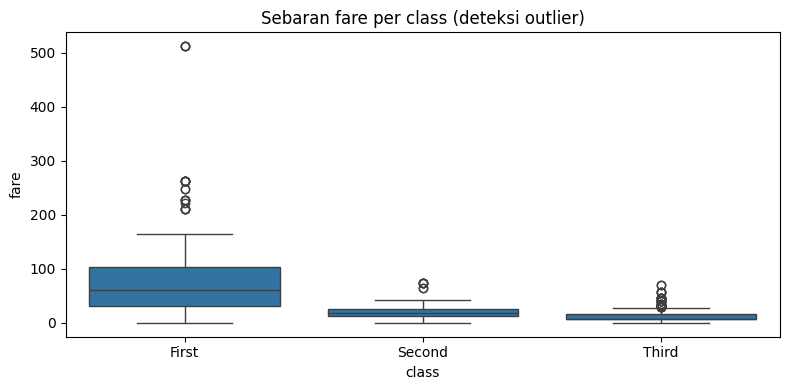

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="class", y="fare")  # distribusi fare per kelas kabin
plt.title("Sebaran fare per class (deteksi outlier)")
plt.tight_layout()
plt.show()